<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
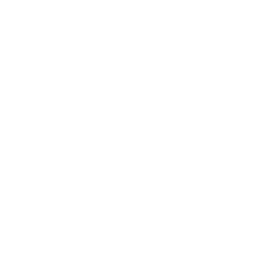
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Split-Plot-Versuchsplan zur Prozessoptimierung</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Fertigung / Qualitätstechnik &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses Notebook analysiert ein Split-Plot-Versuchsdesign für einen
Spritzgussprozess. Der Whole-Plot-Faktor ist die **Maschine** (4 Stufen:
MACH_A-MACH_D), die nur schwer zu wechseln ist, und der Sub-Plot-Faktor ist
die **Drehzahleinstellung** (5 Stufen: 60, 80, 100, 120, 140 U/min), die
leicht zu ändern ist. An jeder Maschine-x-Drehzahl-Kombination werden fünf
Wiederholungsmessungen erfasst, was 100 Fehlerraten-Beobachtungen ergibt.

`PROC MIXED` passt die eingeschränkte Randomisierungsstruktur korrekt an,
indem **Maschine als zufälliger Effekt** (die Whole-Plot-Fehlerebene) und
**Drehzahl als fester Effekt** (der Sub-Plot-Faktor) behandelt wird. Die
Analyse schätzt die beiden Varianzkomponenten, testet den Drehzahleffekt und
erzeugt Tukey-adjustierte paarweise Vergleiche der Drehzahl-Kleinste-
Quadrate-Mittelwerte, um die Betriebsdrehzahl zu identifizieren, die die
Fehlerrate minimiert.


## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Split-Plot-Versuchsdaten: 4 Maschinen x 5 Drehzahlen x 5 Wiederholungen | 100 |


---


In [1]:
/* --------------------------------------------------------
   Erzeugung synthetischer Split-Plot-Daten fuer den Spritzgussprozess
   4 Maschinen (Whole-Plot) x 5 Drehzahlen (Sub-Plot) x 5 Wiederholungen
   Zusaetzliche Wiederholungen je Whole-Plot
   -------------------------------------------------------- */
DATEN work.molding_experiment;
    AUFRUFEN streaminit(42);
    FELD machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    FELD speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Wahre Maschineneffekte (zufaellig) */
    FELD mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Wahre Drehzahleffekte (fest, quadratisch mit Optimum bei ~100) */
    FELD speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    AUSFÜHRUNG whole_plot = 1 BIS 5;
        AUSFÜHRUNG m = 1 BIS 4;
            machine = machine_names[m];
            machine_id = cat('WP_', PUT(whole_plot, z2.), '_', machine);
            /* Whole-Plot-Wiederholungseffekt */
            wp_noise = rand('normal', 0, 1.5);
            AUSFÜHRUNG s = 1 BIS 5;
                speed = speed_settings[s];
                speed_label = cat(PUT(speed, 3.), 'RPM');
                /* Sub-Plot-Wiederholungen innerhalb jedes Whole-Plots */
                AUSFÜHRUNG rep = 1 BIS 5;
                    obs_id + 1;
                    /* Fehlerrate: Achsenabschnitt + Maschine + Drehzahl + Interaktion + Rauschen */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    WENN defect_rate < 0 DANN defect_rate = 0.01;
                    /* Sekundaere Zielgroesse: Zugfestigkeit */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    AUSGABE;
                ENDE;
            ENDE;
        ENDE;
    ENDE;
    ENTFERNEN m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
AUSFÜHREN;



NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---


In [2]:
/* --------------------------------------------------------
   Baseline: Zusammenfassung der Fehlerrate nach Maschine und Drehzahl
   -------------------------------------------------------- */
PROZEDUR MEANS DATEN=work.molding_experiment n mean std;
    KLASSE machine speed_label;
    VAR defect_rate tensile_strength;
    BEZEICHNUNG machine="Maschine" speed_label="Drehzahl (RPM)"
          defect_rate="Fehlerrate (%)" tensile_strength="Zugfestigkeit";
    TITEL 'Fehlerrate und Zugfestigkeit nach Maschine und Drehzahl';
AUSFÜHREN;


                                Fehlerrate und Zugfestigkeit nach Maschine und Drehzahl                                 

                                                  The MEANS Procedure

                                     Analysis Variable : defect_rate Fehlerrate (%)

        Maschine  Drehzahl (RPM)          N Obs           Mean        Std Dev
        ---------------------------------------------------------------------
        MACH_A     60RPM                      5     12.9460000      1.0100149
        MACH_A     80RPM                      5     10.0160000      0.6740401
        MACH_A    100RPM                      5      7.5980000      0.9787083
        MACH_A    120RPM                      5     10.2660000      0.9490416
        MACH_A    140RPM                      5     13.7120000      0.9359594
        MACH_B     60RPM                      5     11.7420000      0.9476656
        MACH_B     80RPM                      5      8.5580000      1.0129018
        MACH_B    10


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                Fehlerrate und Zugfestigkeit nach Maschine und Drehzahl                                 




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


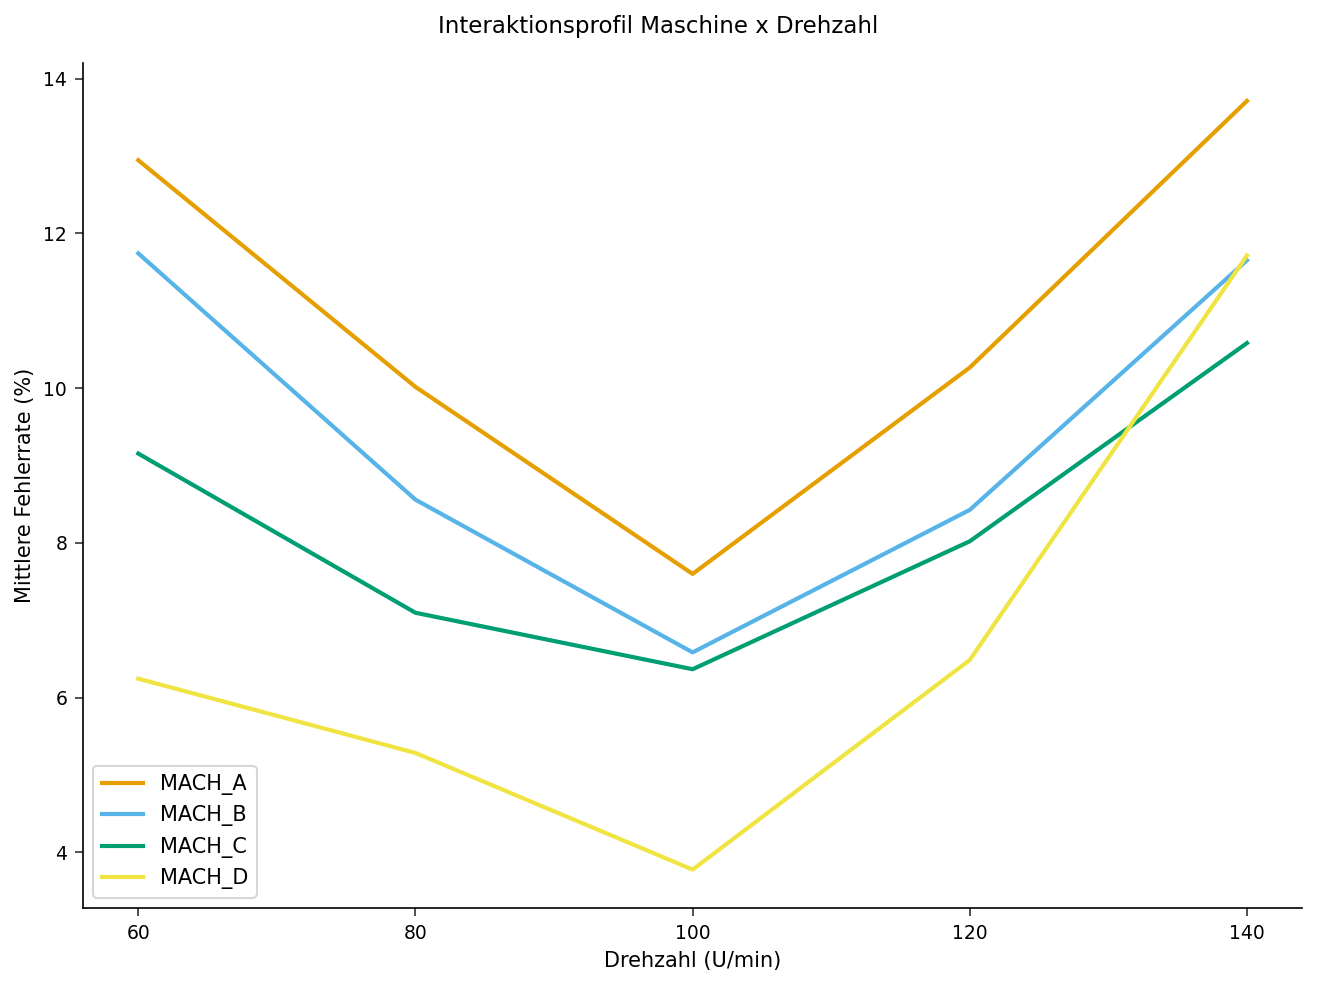

In [3]:
/* --------------------------------------------------------
   Interaktionsplot: mittlere Fehlerrate nach Drehzahl und Maschine
   -------------------------------------------------------- */
PROZEDUR MEANS DATEN=work.molding_experiment NOPRINT;
    KLASSE machine speed;
    VAR defect_rate;
    AUSGABE out=work.cell_means mean=mean_defect;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=work.cell_means(WO=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS BEZEICHNUNG='Drehzahl (U/min)' VALUES=(60 80 100 120 140);
    YAXIS BEZEICHNUNG='Mittlere Fehlerrate (%)';
    TITEL 'Interaktionsprofil Maschine x Drehzahl';
AUSFÜHREN;


---


                                Fehlerrate und Zugfestigkeit nach Maschine und Drehzahl                                 

           The Mixed Procedure           
            Model Information            

Item                                Value
-------------------------  --------------
Dependent Variable         Fehlerrate (%)
Estimation Method                    REML
Degrees of Freedom Method   Kenward-Roger
Number of Observations                100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

           Type III Tests of Fixed Effects            

Effect            Num DF    Den DF   F Value    Pr > F
--------------  --------  --------  --------  --------
Drehzahl (RPM)         4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC (Smaller is Better)  361


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


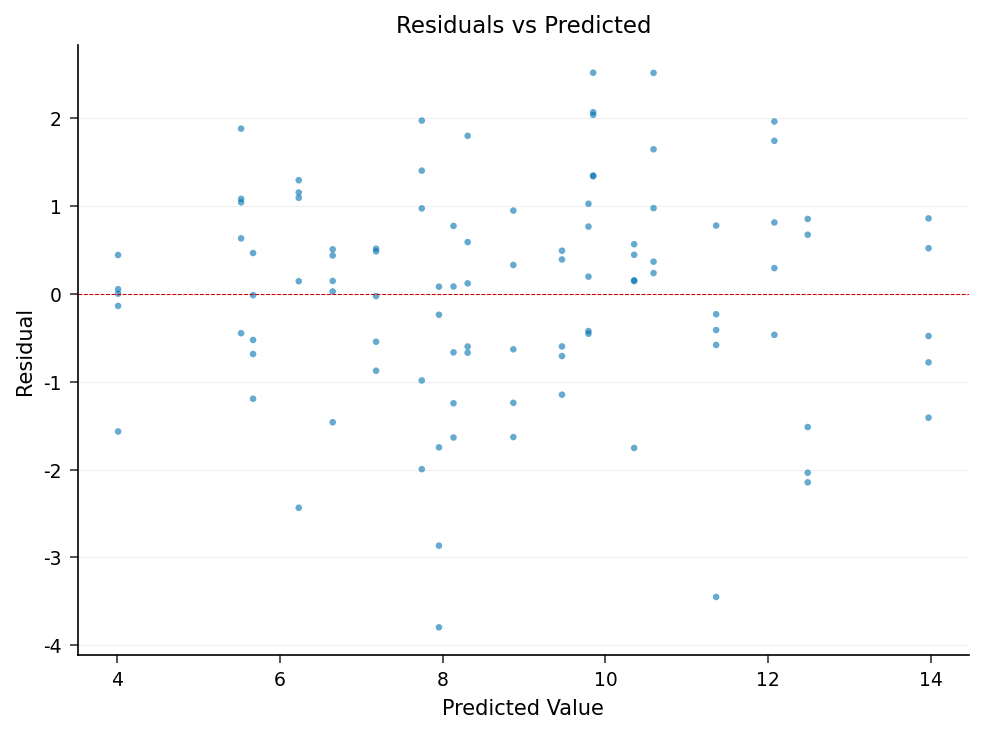

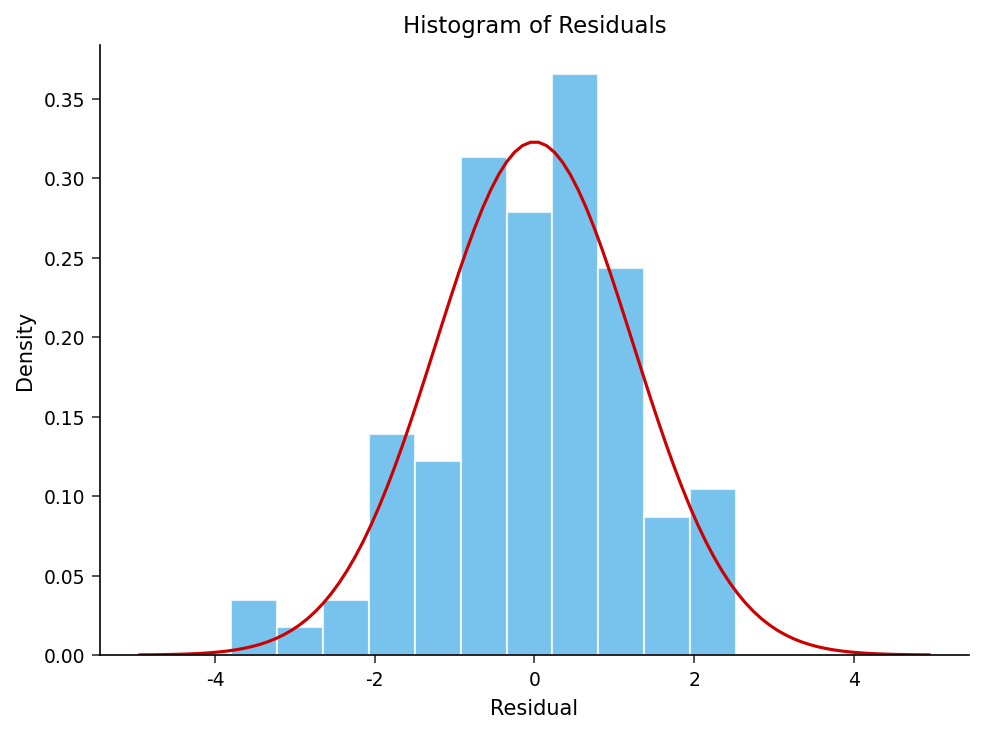

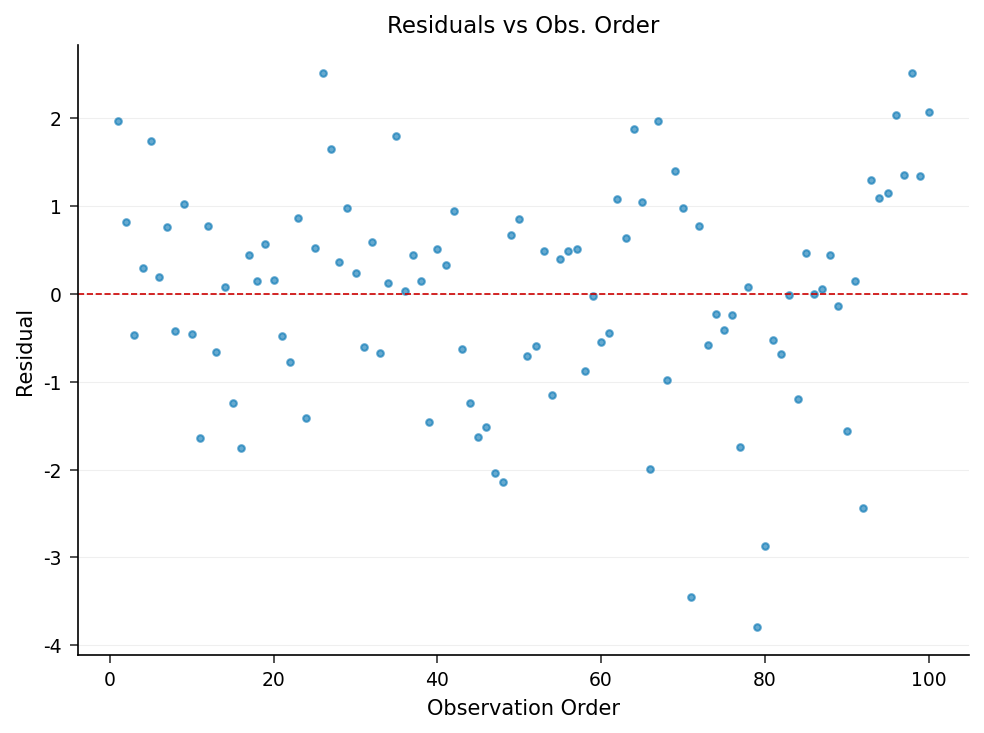

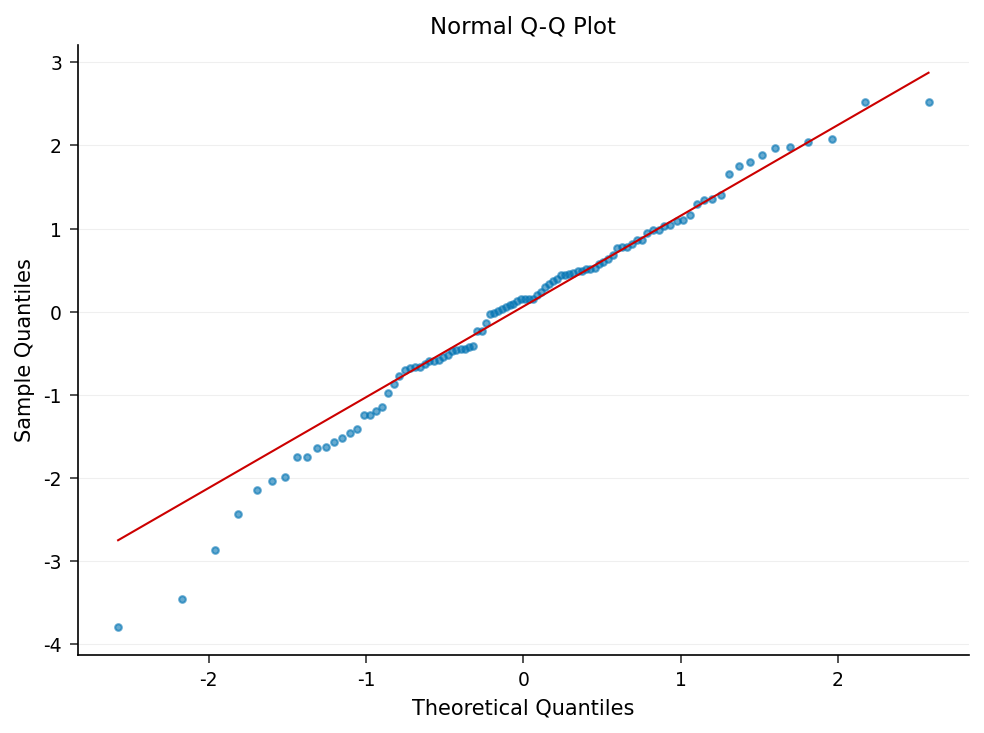

In [4]:
/* --------------------------------------------------------
   Split-Plot-Analyse mit gemischtem Modell
   Maschine ist zufaellig (Whole-Plot-Fehlerebene)
   Drehzahl ist fest (Sub-Plot-Faktor)
   -------------------------------------------------------- */
PROZEDUR MIXED DATEN=work.molding_experiment METHOD=reml;
    KLASSE machine speed_label;
    MODELL defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    BEZEICHNUNG defect_rate="Fehlerrate (%)" speed_label="Drehzahl (RPM)";
    ODS AUSGABE LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    TITEL 'Split-Plot-Analyse: Effekt der Drehzahl auf die Fehlerrate';
AUSFÜHREN;


In [5]:
/* --------------------------------------------------------
   Ermittlung der optimalen Drehzahl
   -------------------------------------------------------- */
PROZEDUR SORT DATEN=work.speed_lsmeans;
    NACH estimate;
AUSFÜHREN;

DATEN work.optimal_speed;
    FESTLEGEN work.speed_lsmeans(obs=1);
    BEHALTEN speed_label estimate stderr LOWER UPPER;
    BEZEICHNUNG speed_label = 'Optimale Drehzahl'
          estimate = 'LS-Mittelwert Fehlerrate'
          stderr = 'Standardfehler'
          LOWER = '95%-KI Untergrenze'
          UPPER = '95%-KI Obergrenze';
AUSFÜHREN;

PROZEDUR PRINT DATEN=work.optimal_speed noobs BEZEICHNUNG;
    TITEL 'Empfohlene Betriebsdrehzahl fuer minimale Fehlerrate';
AUSFÜHREN;


                                  Empfohlene Betriebsdrehzahl fuer minimale Fehlerrate                                  

Optimale Drehzahl  LS-Mittelwert Fehlerrate  Standardfehler  95%-KI Untergrenze  95%-KI Obergrenze
                .                     6.081          0.9266              3.3645             8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Zerlegung der Varianzkomponenten
   -------------------------------------------------------- */
PROZEDUR PRINT DATEN=work.split_covparms noobs;
    TITEL 'Varianzkomponenten: Maschine vs. Residuum';
AUSFÜHREN;


                                       Varianzkomponenten: Maschine vs. Residuum                                        

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---


### Interpretation

Das Split-Plot-Modell zerlegt die Variabilität der Fehlerrate in zwei
Schichten. Die **Maschinen-(Whole-Plot-)Varianzkomponente beträgt 3.10** und
die **Residual-(Sub-Plot-)Varianz beträgt 1.66**, sodass Unterschiede
zwischen Maschinen etwa **65 %** der Gesamtvarianz ausmachen (3.10 / (3.10 +
1.66)). Dieser große Anteil zwischen den Maschinen bestätigt, dass die
Maschine eine echte Quelle der Prozessvariation ist und dass das
Split-Plot-Design - und nicht eine vollständig randomisierte Analyse - der
richtige Rahmen ist.

Der Typ-III-Test des festen Drehzahleffekts ist hochsignifikant:
**F(4, 92) = 60.26, p < .0001**, die Drehzahleinstellung beeinflusst die
Fehlerrate also stark. Die Kleinste-Quadrate-Mittelwerte zeichnen eine klare
quadratische Reaktion mit einem Minimum bei der mittleren Drehzahl:

| Drehzahl | LS-Mittelwert Fehlerrate (%) | 95 %-KI |
|-------|------------------------|--------|
| **100 U/min** | **6.08** | 3.36 - 8.80 |
| 80 U/min | 7.74 | 5.02 - 10.46 |
| 120 U/min | 8.30 | 5.58 - 11.02 |
| 60 U/min | 10.02 | 7.31 - 12.74 |
| 140 U/min | 11.92 | 9.20 - 14.63 |

Tukey-adjustierte paarweise Vergleiche zeigen, dass **100 U/min signifikant
niedriger liegt als jede andere Einstellung** (adjustiertes p <= 0.0009
gegenüber 80, 120, 60 und 140 U/min). Die Einstellungen 80 U/min und
120 U/min liegen in der Mitte und unterscheiden sich **nicht** voneinander
(Differenz 0.56, adjustiertes p = 0.6430), während 60 U/min und 140 U/min
die höchsten Fehlerraten ergeben.

**Empfehlung für die Praxis:** Die Produktion an allen vier Maschinen auf
**100 U/min** standardisieren, wo das Modell die niedrigste Fehlerrate
schätzt (6.08 %). Da die Maschinen-Varianzkomponente (3.10) die dominierende
Quelle der Variabilität ist, sollte die Folgearbeit auf eine
maschinenspezifische Kalibrierung abzielen - das Interaktionsprofil zeigt,
dass MACH_D durchgängig am niedrigsten und MACH_A am höchsten liegt -, um die
Lücke zwischen den Maschinen beim gewählten Arbeitspunkt von 100 U/min zu
schließen.


---


In [7]:
/* --------------------------------------------------------
   Export der Drehzahloptimierungsergebnisse fuer die Konstruktion
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;



NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>